In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---


**Phase - 1 : Analysis of features in all table and verification of interconnections among the tables**


---

In [ ]:
# Reading tables and storing them in Variables #

import pandas as pd
import numpy as np


folder_path = "/content/drive/MyDrive/Patient_readmission_dataset/" # <--- ADJUST THIS PATH

patients = pd.read_csv(f"{folder_path}patients.csv")
admissions = pd.read_csv(f"{folder_path}admissions.csv")
diagnoses = pd.read_csv(f"{folder_path}diagnoses.csv")
billing = pd.read_csv(f"{folder_path}billing.csv")
hospitals = pd.read_csv(f"{folder_path}hospitals.csv")

In [ ]:
# Obtaining size of the tables #

tables ={
    "patients":patients,
    "admissions":admissions,
    "diagnoses":diagnoses,
    "billing":billing,
    "hospitals":hospitals
}

for name,df in tables.items():
  print(f"{name:<12} : {df.shape[0]:,} rows x {df.shape[1]} columns")

patients     : 86,400 rows x 8 columns
admissions   : 120,000 rows x 17 columns
diagnoses    : 271,341 rows x 6 columns
billing      : 120,000 rows x 6 columns
hospitals    : 33 rows x 6 columns


In [ ]:
# Checking the datatypes in each column of the table #

for name, df in tables.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.dtypes)
    print()

PATIENTS
patient_id           object
age                   int64
gender               object
state                object
bpl_card               bool
insurance_type       object
comorbidity_count     int64
prev_admissions       int64
dtype: object

ADMISSIONS
admission_id       object
patient_id         object
admit_date         object
discharge_date     object
los_days            int64
admit_type         object
ward_type          object
hospital_id        object
discharge_type     object
num_procedures      int64
charlson_index      int64
hba1c             float64
creatinine        float64
haemoglobin       float64
systolic_bp         int64
readmitted_30d      int64
readmitted_7d       int64
dtype: object

DIAGNOSES
diag_id          object
admission_id     object
icd10_code       object
diag_desc        object
diag_rank         int64
diag_category    object
dtype: object

BILLING
bill_id              object
admission_id         object
total_cost_inr        int64
govt_subsidy_inr      i

In [ ]:
# Checking the null values, if any #

for name, df in tables.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.isnull().sum())
    print()

PATIENTS
patient_id               0
age                      0
gender                   0
state                    0
bpl_card                 0
insurance_type       24715
comorbidity_count        0
prev_admissions          0
dtype: int64

ADMISSIONS
admission_id      0
patient_id        0
admit_date        0
discharge_date    0
los_days          0
admit_type        0
ward_type         0
hospital_id       0
discharge_type    0
num_procedures    0
charlson_index    0
hba1c             0
creatinine        0
haemoglobin       0
systolic_bp       0
readmitted_30d    0
readmitted_7d     0
dtype: int64

DIAGNOSES
diag_id          0
admission_id     0
icd10_code       0
diag_desc        0
diag_rank        0
diag_category    0
dtype: int64

BILLING
bill_id              0
admission_id         0
total_cost_inr       0
govt_subsidy_inr     0
out_of_pocket_inr    0
cost_category        0
dtype: int64

HOSPITALS
hospital_id    0
name           0
state          0
tier           0
beds           0
tea

In [ ]:
# Validation of Foreign keys by checking their primary tables #

print("Admissions -> Patients")
print(admissions["patient_id"].isin(patients["patient_id"]).all())

print("\nAdmissions -> Hospitals")
print(admissions["hospital_id"].isin(hospitals["hospital_id"]).all())

print("\nDiagnoses -> Admissions")
print(diagnoses["admission_id"].isin(admissions["admission_id"]).all())

print("\nBilling -> Admissions")
print(billing["admission_id"].isin(admissions["admission_id"]).all())

Admissions -> Patients
True

Admissions -> Hospitals
True

Diagnoses -> Admissions
True

Billing -> Admissions
True


All are , therefore all the foreign keys present in the admissions table are actually primary keys in their respective tables.

---


**Phase - 2: Exploratory Data Analysis (EDA) of all 5 tables in our dataset**

---



In [ ]:
# Distribution of the target variable #

target_counts = admissions["readmitted_30d"].value_counts().sort_index()

print(target_counts)

print("\nPercentage Distribution:")
print((target_counts / len(admissions) * 100).round(2))

readmitted_30d
0    105790
1     14210
Name: count, dtype: int64

Percentage Distribution:
readmitted_30d
0    88.16
1    11.84
Name: count, dtype: float64


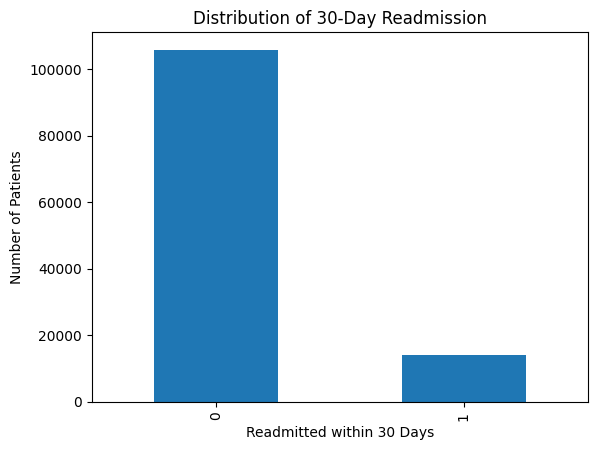

In [ ]:
# Plotting of Target Variable (Readmission within 30d) to determine No.of Patients Readmitted within 30days #

import matplotlib.pyplot as plt

target_counts.plot(kind="bar")

plt.title("Distribution of 30-Day Readmission")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
print("Gender")
print(patients["gender"].value_counts(dropna=False))

print("\nInsurance Type")
print(patients["insurance_type"].value_counts(dropna=False))

print("\nState")
print(patients["state"].value_counts())

Gender
gender
M        44190
F        41361
Other      849
Name: count, dtype: int64

Insurance Type
insurance_type
Ayushman    25967
NaN         24715
Private     21372
ESI         14346
Name: count, dtype: int64

State
state
Maharashtra       9633
Uttar Pradesh     8867
Tamil Nadu        7962
Karnataka         7253
West Bengal       6709
Telangana         6293
Gujarat           5864
Andhra Pradesh    5684
Kerala            5180
Rajasthan         4748
Madhya Pradesh    4181
Haryana           4108
Punjab            3632
Odisha            3290
Bihar             2996
Name: count, dtype: int64


In [ ]:
# Inspection of Main table (Admissions) #

admissions.describe(include="all")

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
count,120000,120000,120000,120000,120000.000000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
unique,120000,64873,3652,3677,NaN,3,4,33,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,a9d5a2bc-3312-449c-851c-4d284fbad4b1,dd0ca7f5-a2e4-4077-8602-49690edaca7e,2019-07-06,2020-07-01,NaN,Emergency,General,a86650ea-3517-4285-bc11-ffa2085a8df2,Recovered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,10,56,56,NaN,66540,76768,3736,87420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.852708,NaN,NaN,NaN,NaN,1.523742,1.894858,5.869862,1.070463,11.840079,134.628075,0.118417,0.008383
std,NaN,NaN,NaN,NaN,5.708269,NaN,NaN,NaN,NaN,1.542197,1.610380,1.061662,0.896135,2.171929,20.756544,0.323102,0.091176
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,4.000000,0.400000,4.000000,70.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,5.300000,0.770000,10.400000,120.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,5.700000,0.910000,11.900000,134.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,2.000000,3.000000,6.100000,1.100000,13.300000,148.000000,0.000000,0.000000


In [ ]:
categorical_cols = [
    "admit_type",
    "ward_type",
    "discharge_type"
]

for col in categorical_cols:
    print(f"\n{'='*40}")
    print(col)
    print(admissions[col].value_counts(dropna=False))


admit_type
admit_type
Emergency    66540
Elective     37853
OPD          15607
Name: count, dtype: int64

ward_type
ward_type
General    76768
ICU        20833
HDU        15907
NICU        6492
Name: count, dtype: int64

discharge_type
discharge_type
Recovered    87420
LAMA         15429
Referred      9738
Expired       7413
Name: count, dtype: int64


In [ ]:
# Checking the relation of "Target Variable (Readmitted_30d)" with "Length of stay in Hospital" #

import pandas as pd

admissions.groupby("readmitted_30d")["los_days"].describe().transpose()

readmitted_30d,0,1
count,105790.000000,14210.000000
mean,6.396209,10.251232
std,5.152928,8.024424
min,1.000000,1.000000
25%,3.000000,4.000000
50%,5.000000,8.000000
75%,8.000000,14.000000
max,63.000000,90.000000


So, the results indicates that the feature "length of stay" contributes upto some extent for readmission as the readmitted patients has high mean and median values than non-readmitted patients.

In [ ]:
# Checking the relation of "Target Variable (Readmitted_30d)" with "Charlson Comorbidity Index" #

admissions.groupby("readmitted_30d")["charlson_index"].describe().transpose()

readmitted_30d,0,1
count,105790.000000,14210.000000
mean,1.777314,2.769951
std,1.564846,1.673694
min,0.000000,0.000000
25%,0.000000,1.000000
50%,2.000000,3.000000
75%,3.000000,4.000000
max,6.000000,6.000000


So, the results indicates that the feature "Charlson Comorbidity Index" contributes upto some extent for readmission as the readmitted patients has high mean and median values than non-readmitted patients.

In [ ]:
# Comparing numeric features vs readmission status using Mann-Whitney U Test
from scipy.stats import mannwhitneyu
import pandas as pd

# Merge to align patient features with admission-level target variable
merged_df = pd.merge(admissions, patients, on="patient_id")

numeric_cols = [
    "age",
    "prev_admissions",
    "comorbidity_count",
    "los_days",
    "num_procedures",
    "charlson_index",
    "hba1c",
    "creatinine",
    "haemoglobin",
    "systolic_bp"
]

results = []

for col in numeric_cols:
    # Using merged_df to ensure all columns are accessible
    g0 = merged_df[merged_df["readmitted_30d"] == 0][col]
    g1 = merged_df[merged_df["readmitted_30d"] == 1][col]

    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")

    results.append({
        "Feature": col,
        "P-value": p,
        "U-Static":stat,
        "Significant": p < 0.05
    })

# Display summary of results
pd.DataFrame(results).sort_values("P-value")

,Feature,P-value,U-Static,Significant
0,age,0.000000e+00,527989153.5,True
1,prev_admissions,0.000000e+00,576605500.0,True
2,comorbidity_count,0.000000e+00,498715075.0,True
3,los_days,0.000000e+00,506488333.0,True
4,num_procedures,0.000000e+00,567621345.5,True
5,charlson_index,0.000000e+00,500585435.5,True
8,haemoglobin,0.000000e+00,925707035.0,True
9,systolic_bp,6.191336e-201,634386220.5,True
7,creatinine,2.721057e-04,737524068.5,True
6,hba1c,1.051527e-02,761543744.0,True


With reference to above test,

Our **Null hypothesis :**
 feature's distribution ("age", prev_admissions", "comorbidity_count", "los_days", "num_procedures", "charlson_index", "hba1c", "creatinine","haemoglobin" ,"systolic_bp") does not differs between readmitted and non-readmitted patients.


 **Alternate Hypothesis :**
Feature's distribution differ between readmitted and non-readmitted patients.

**Conclusion:** As the P-value is less than 0.05 for all the above said features, we fail to accept the null hypothesis. Hence we can say that all the above said feature's distribution differs between readmitted and non-readmitted patients.

In [ ]:
# Similar to Mann-whitney U Test for Numerical data, we perform Chi Square test for categorical data #

from scipy.stats import chi2_contingency

categorical_cols = [
    "gender",
    "insurance_type",
    "state",
    "admit_type",
    "ward_type",
    "discharge_type"
]

results = []

for col in categorical_cols:

    contingency_table = pd.crosstab(merged_df[col], merged_df["readmitted_30d"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        "Feature": col,
        "Chi2 Statistic": chi2,
        "Degrees of Freedom": dof,
        "P-value": p_value,
        "Significant (p < 0.05)": p_value < 0.05
    })

chi_results = (
    pd.DataFrame(results)
      .sort_values("P-value")
      .reset_index(drop=True)
)

chi_results


,Feature,Chi2 Statistic,Degrees of Freedom,P-value,Significant (p < 0.05)
0,discharge_type,1521.497466,3,0.000000e+00,True
1,ward_type,4151.042154,3,0.000000e+00,True
2,admit_type,1267.895522,2,4.786141e-276,True
3,insurance_type,332.845205,2,5.291540e-73,True
4,gender,4.628263,2,9.885201e-02,False
5,state,19.669694,14,1.409039e-01,False


With reference to Chi Square test,

Our **Null hypothesis :** Categorical feature's distribution ("gender", "insurance_type", "state", "admit_type", "ward_type", "discharge_type") does not differs between readmitted and non-readmitted patients.

**Alternate Hypothesis :** Categorical Feature's distribution differ between readmitted and non-readmitted patients.

**Conclusion:** The P-Value for all the features except gender and state is less than 0.05, so it is statistically evident that, all the above said categorical features except gender and state differ between readmitted and non-readmitted patients.

**Note :** Though the Gender and State has high P-Value due to which we may accept Null Hypothesis, but they may show effect if combined with other features, so do not drop the columns Gender and State until we 100% confirm that they're no where related to the feature "readmission within 30days".


In [ ]:
from scipy.stats import chi2_contingency

results = []

for col in categorical_cols:

    contingency = pd.crosstab(merged_df[col], merged_df["readmitted_30d"])

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()

    r, c = contingency.shape

    cramers_v = np.sqrt(
        chi2 / (n * (min(r, c) - 1))
    )

    results.append({
        "Feature": col,
        "Chi2": chi2,
        "P-value": p,
        "Cramers V": cramers_v
    })

cramers_df = (
    pd.DataFrame(results)
      .sort_values("Cramers V", ascending=False)
      .reset_index(drop=True)
)

cramers_df

,Feature,Chi2,P-value,Cramers V
0,ward_type,4151.042154,0.000000e+00,0.185989
1,discharge_type,1521.497466,0.000000e+00,0.112602
2,admit_type,1267.895522,4.786141e-276,0.102790
3,insurance_type,332.845205,5.291540e-73,0.062207
4,state,19.669694,1.409039e-01,0.012803
5,gender,4.628263,9.885201e-02,0.006210


With reference to Cramers V test, we can say that **no categorical feature** (ward_type, discharge_type, admit_type, insurance_type, state, gender) **exhibit a strong relationship** with our target variable **"readmission within 30days"**. But we do not drop them as of now, since they may be collectively used further.

In [ ]:
# We've completed EDA for 02 tables (viz Admissions & Patients) out of 05 tables. #
# We'll proceed with EDA for remaining 03 tables viz Diagnoses, Billing and Hospitals #

print(f"shape is {diagnoses.shape}\n")
diagnoses.head()


shape is (271341, 6)



,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological
3,754ec3d2-e940-4342-9e1d-d88a9acec626,cc4849fa-b740-487b-beda-3086a18273c0,A15,Pulmonary tuberculosis,2,Infectious
4,f4fa0d7b-0a68-4dd9-b7cf-db15c6bf3812,cc4849fa-b740-487b-beda-3086a18273c0,I48,Atrial fibrillation,3,Cardiovascular


In [ ]:
diagnoses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271341 entries, 0 to 271340
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   diag_id        271341 non-null  object
 1   admission_id   271341 non-null  object
 2   icd10_code     271341 non-null  object
 3   diag_desc      271341 non-null  object
 4   diag_rank      271341 non-null  int64 
 5   diag_category  271341 non-null  object
dtypes: int64(1), object(5)
memory usage: 12.4+ MB


In [ ]:
diagnoses.describe(include="all")

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
count,271341,271341,271341,271341,271341.000000,271341
unique,271341,120000,34,34,NaN,11
top,d57296a5-6ff6-453c-bc2c-66a777a319d7,bcca7977-7c90-4bc4-89c7-3d8711e82b96,E10,Type 1 diabetes mellitus,NaN,Cardiovascular
freq,1,4,12079,12079,NaN,53410
mean,NaN,NaN,NaN,NaN,1.926867,NaN
std,NaN,NaN,NaN,NaN,0.998618,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,1.000000,NaN
50%,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,3.000000,NaN


In [ ]:
diagnoses.isnull().sum()

,0
diag_id,0
admission_id,0
icd10_code,0
diag_desc,0
diag_rank,0
diag_category,0


In [ ]:
diagnoses.duplicated().sum()

np.int64(0)

With reference to above results, we came to know that single admission may have multiple diseases/diagnosis. So we must adjust the data present in diagnosis table to fit our master table "merged_df" which contains the admissions and patients details.

In [ ]:
# This will tell us whether most admissions have 1 diagnosis or several. #
diagnoses.groupby("admission_id").size().describe()

,0
count,120000.000000
mean,2.261175
std,1.157536
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [ ]:
# This verifies how many primary, secondary, tertiary, and quaternary diagnoses exist. #

diagnoses["diag_rank"].value_counts().sort_index()

,count
diag_rank,
1,120000
2,77128
3,48270
4,25943


In [ ]:
# This identifies the most common disease groups. #

diagnoses["diag_category"].value_counts()

,count
diag_category,
Cardiovascular,53410
Endocrine,35491
Respiratory,30648
Infectious,30397
Gastrointestinal,23601
Neoplasm,21776
Injury,17278
Neurological,17111
Genitourinary,16591


In [ ]:
diagnoses["icd10_code"].value_counts()

,count
icd10_code,
E10,12079
E11,12025
I48,11401
E87,11387
I10,11370
I50,11282
I21,11236
N18,11202
K57,9173


From the above analysis, we came to know that the admission might consists of multiple diseases along with primary disease.

In [ ]:
# We'll check the contribution of Primary Disease for readmission #

primary_diag = diagnoses[diagnoses["diag_rank"] == 1]

diag_readmission = (
    primary_diag.merge(
        admissions[["admission_id", "readmitted_30d"]],
        on="admission_id"
    )
    .groupby("diag_desc")
    .agg(
        Total_Patients=("readmitted_30d", "count"),
        Readmission_Rate=("readmitted_30d", "mean")
    )
    .sort_values("Readmission_Rate", ascending=False)
)

diag_readmission

,Total_Patients,Readmission_Rate
diag_desc,,
Sepsis,1935,0.299225
Respiratory failure,3211,0.293989
Cerebral infarction,3240,0.230864
Intracranial injury,2074,0.220829
Acute myocardial infarction,5219,0.215750
Heart failure,5154,0.212456
Respiratory distress — newborn,2654,0.204974
Disorders — short gestation,2704,0.167899
COPD,3315,0.156259


Since our overall dataset has a readmission rate of approximately **11.84%**, this serves as our baseline.

If a diagnosis description (disease names) has a rate above **11.84%**, it is associated with a higher-than-average readmission risk.
If it is below **11.84%**, it is associated with a lower-than-average risk.

In [ ]:
# Now we'll perform One hot encoding and inject all the diseases into our master table #

# One-hot encode diagnosis categories
diag_features = pd.get_dummies(
    diagnoses["diag_desc"],
    prefix="has",
    dtype=int
)

# Attach admission_id
diag_features["admission_id"] = diagnoses["admission_id"]

# Aggregate to one row per admission
diag_features = (
    diag_features
    .groupby("admission_id")
    .max()
    .reset_index()
)

diag_features.head()

,admission_id,has_Acute myocardial infarction,has_Alcoholic liver disease,has_Asthma,has_Atrial fibrillation,has_COPD,has_Cerebral infarction,has_Cholelithiasis,has_Chronic kidney disease,has_Dengue haemorrhagic fever,...,has_Pulmonary tuberculosis,has_Respiratory distress — newborn,has_Respiratory failure,has_Sepsis,has_Single spontaneous delivery,has_Type 1 diabetes mellitus,has_Type 2 diabetes mellitus,has_Unspecified injury,has_Unspecified malaria,has_Urinary tract infection
0,0001273a-4e21-47f3-8dff-877734fb010c,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,00020220-ca07-4b22-bed3-934e565d2875,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0003b202-ff44-43ac-bc52-6075f4ecddf9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0004897e-6c81-44ed-bc91-b9ae47bedced,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,000616dc-80eb-4a95-a8cd-60245916a9a9,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Join the modified Diagnosis table with our master table "merged_df"
# We check for existing columns to avoid duplicates on re-execution
new_cols = [c for c in diag_features.columns if c not in merged_df.columns or c == 'admission_id']

merged_df = merged_df.merge(
    diag_features[new_cols],
    on="admission_id",
    how="left"
)

merged_df.head()

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,...,has_Pulmonary tuberculosis,has_Respiratory distress — newborn,has_Respiratory failure,has_Sepsis,has_Single spontaneous delivery,has_Type 1 diabetes mellitus,has_Type 2 diabetes mellitus,has_Unspecified injury,has_Unspecified malaria,has_Urinary tract infection
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,...,0,0,0,0,0,0,0,0,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,0,0,0,0,0,0,0,0,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,...,1,0,0,0,0,0,0,0,0,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,...,0,0,0,0,0,0,0,0,0,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
merged_df.columns.tolist()

['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'has_Acute myocardial infarction',
 'has_Alcoholic liver disease',
 'has_Asthma',
 'has_Atrial fibrillation',
 'has_COPD',
 'has_Cerebral infarction',
 'has_Cholelithiasis',
 'has_Chronic kidney disease',
 'has_Dengue haemorrhagic fever',
 'has_Disorders — short gestation',
 'has_Diverticular disease of colon',
 'has_Epilepsy',
 'has_Essential hypertension',
 'has_Fracture of femur',
 'has_Gastroenteritis and colitis',
 'has_Heart failure',
 'has_Intracranial injury',
 'has_Malignant neoplasm — breast',
 'has_Malignant neoplasm — colon',
 'has_Malignant neoplasm — lung',
 'has_Maternal care — uterine anomaly',
 'h

In [ ]:
# Nomenclature correction of columns #
import re

def clean_column(col):
    # Convert to lowercase
    col = col.lower()

    # Replace has with dx
    col = col.replace("has", "dx")

    # Replace em dash and en dash with underscore
    col = col.replace("—", "_")

    # Replace slash with underscore
    col = col.replace("/", "_")

    # Replace commas with nothing
    col = col.replace(",", "")

    # Replace spaces with underscore
    col = col.replace(" ", "_")

    # Remove anything that is not a-z, 0-9 or underscore
    col = re.sub(r"[^a-z0-9_]", "", col)

    # Remove multiple underscores
    col = re.sub(r"_+", "_", col)

    # Remove leading/trailing underscores
    col = col.strip("_")

    return col

merged_df.rename(
    columns={c: clean_column(c) for c in merged_df.columns},
    inplace=True
)

In [ ]:
merged_df.columns.tolist()

['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'dx_acute_myocardial_infarction',
 'dx_alcoholic_liver_disease',
 'dx_asthma',
 'dx_atrial_fibrillation',
 'dx_copd',
 'dx_cerebral_infarction',
 'dx_cholelithiasis',
 'dx_chronic_kidney_disease',
 'dx_dengue_haemorrhagic_fever',
 'dx_disorders_short_gestation',
 'dx_diverticular_disease_of_colon',
 'dx_epilepsy',
 'dx_essential_hypertension',
 'dx_fracture_of_femur',
 'dx_gastroenteritis_and_colitis',
 'dx_heart_failure',
 'dx_intracranial_injury',
 'dx_malignant_neoplasm_breast',
 'dx_malignant_neoplasm_colon',
 'dx_malignant_neoplasm_lung',
 'dx_maternal_care_uterine_anomaly',
 'dx_metabolic_electrolyte_disorde

In [ ]:
disease_cols = [col for col in merged_df.columns if col.startswith("dx_")]

disease_summary = []

for col in disease_cols:
    patients_with_disease = merged_df[merged_df[col] == 1]

    disease_summary.append({
        "Disease": col,
        "Patients": len(patients_with_disease),
        "Readmission Rate (%)": patients_with_disease["readmitted_30d"].mean() * 100
    })

disease_summary = (
    pd.DataFrame(disease_summary)
      .sort_values("Readmission Rate (%)", ascending=False)
)

disease_summary

,Disease,Patients,Readmission Rate (%)
26,dx_respiratory_failure,8170,23.231334
27,dx_sepsis,5246,22.226458
5,dx_cerebral_infarction,8121,20.108361
0,dx_acute_myocardial_infarction,11236,19.232823
15,dx_heart_failure,11282,18.941677
16,dx_intracranial_injury,5365,18.788444
25,dx_respiratory_distress_newborn,6049,17.986444
4,dx_copd,8303,17.824883
19,dx_malignant_neoplasm_lung,8214,17.202337
9,dx_disorders_short_gestation,6016,16.805186


Based on above results, we came to know that every diseases has a significant readmission rate. As our readmission rate in the whole dataset is **11.84%**, we can consider the diseases with readmission rate **>11.84%** as Critical Diseases. Now we'll go for Chi-Square and Cramer's V Test on the target variable readmission vs diseases.

In [ ]:
disease_cols = [col for col in merged_df.columns if col.startswith("dx_")]

chi_results = []

for col in disease_cols:

    # Contingency table
    contingency = pd.crosstab(merged_df[col], merged_df["readmitted_30d"])

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        "Disease": col,
        "Chi-square": round(chi2, 2),
        "Degrees of Freedom": dof,
        "P-value": p_value
    })

chi_results = (
    pd.DataFrame(chi_results)
      .sort_values("Chi-square", ascending=False)
      .reset_index(drop=True)
)

chi_results

,Disease,Chi-square,Degrees of Freedom,P-value
0,dx_respiratory_failure,1088.24,1,1.189119e-238
1,dx_acute_myocardial_infarction,647.94,1,6.274979e-143
2,dx_heart_failure,600.57,1,1.256949e-132
3,dx_cerebral_infarction,569.35,1,7.758501e-126
4,dx_sepsis,565.67,1,4.910315e-125
5,dx_copd,305.28,1,2.334790e-68
6,dx_intracranial_injury,258.92,1,2.957307e-58
7,dx_malignant_neoplasm_lung,242.17,1,1.321735e-54
8,dx_chronic_kidney_disease,237.68,1,1.261540e-53
9,dx_respiratory_distress_newborn,229.78,1,6.655223e-52


**25 out of 34 diseases** show a statistically significant association with 30-day readmission.

**9 diseases** do not show a significant univariate association with readmission. but we don't remove them now. we'll check their effectiveness after combining with other features like age, previous admissions etc., and will remove them post statistical evidence.

In [ ]:
disease_cols = [col for col in merged_df.columns if col.startswith("dx_")]

cramers_results = []

for col in disease_cols:

    # Contingency table
    contingency = pd.crosstab(
        merged_df[col],
        merged_df["readmitted_30d"]
    )

    # Chi-square
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Sample size
    n = contingency.values.sum()

    # Cramer's V
    r, c = contingency.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

    cramers_results.append({
        "Disease": col,
        "Chi-square": round(chi2, 2),
        "P-value": p,
        "Cramer's V": round(cramers_v, 4)
    })

cramers_results = (
    pd.DataFrame(cramers_results)
      .sort_values("Cramer's V", ascending=False)
      .reset_index(drop=True)
)

cramers_results

,Disease,Chi-square,P-value,Cramer's V
0,dx_respiratory_failure,1088.24,1.189119e-238,0.0952
1,dx_acute_myocardial_infarction,647.94,6.274979e-143,0.0735
2,dx_heart_failure,600.57,1.256949e-132,0.0707
3,dx_cerebral_infarction,569.35,7.758501e-126,0.0689
4,dx_sepsis,565.67,4.910315e-125,0.0687
5,dx_copd,305.28,2.334790e-68,0.0504
6,dx_intracranial_injury,258.92,2.957307e-58,0.0465
7,dx_malignant_neoplasm_lung,242.17,1.321735e-54,0.0449
8,dx_chronic_kidney_disease,237.68,1.261540e-53,0.0445
9,dx_respiratory_distress_newborn,229.78,6.655223e-52,0.0438


Till this point, we've merged the useful features which were present in **03 tables (Admissions, Patient and Diagnoses tables)** with our master table. Now we'll proceed for merging of useful features present in remaining **02 tables (Billing and Hospitals)**.

In [ ]:
print("Shape:", billing.shape)

billing.info()

billing.head()

Shape: (120000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   bill_id            120000 non-null  object
 1   admission_id       120000 non-null  object
 2   total_cost_inr     120000 non-null  int64 
 3   govt_subsidy_inr   120000 non-null  int64 
 4   out_of_pocket_inr  120000 non-null  int64 
 5   cost_category      120000 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.5+ MB


,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room
3,32f41176-c088-4e9a-aa81-ae40f91b912a,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,72588,0,72588,Lab
4,cf80fba9-7fec-4b2e-b548-037a43dcf93c,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,9510,0,9510,Lab


In [ ]:
# Missing values
billing.isnull().sum()

,0
bill_id,0
admission_id,0
total_cost_inr,0
govt_subsidy_inr,0
out_of_pocket_inr,0
cost_category,0


In [ ]:
# Duplicate rows
billing.duplicated().sum()

np.int64(0)

In [ ]:
# Unique values
billing.nunique()

,0
bill_id,120000
admission_id,120000
total_cost_inr,76298
govt_subsidy_inr,56756
out_of_pocket_inr,51467
cost_category,4


In [ ]:
billing.describe()

,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr
count,1.200000e+05,1.200000e+05,1.200000e+05
mean,9.577953e+04,4.760617e+04,4.817336e+04
std,1.955118e+05,1.062371e+05,1.395519e+05
min,6.490000e+02,0.000000e+00,0.000000e+00
25%,1.202300e+04,0.000000e+00,0.000000e+00
50%,3.097050e+04,1.214550e+04,7.636000e+03
75%,8.940700e+04,4.585575e+04,3.334100e+04
max,6.674008e+06,4.606120e+06,4.648583e+06


In [ ]:
billing["cost_category"].value_counts()

,count
cost_category,
Pharmacy,36280
Procedure,33536
Room,29988
Lab,20196


In [ ]:
billing_analysis = billing.merge(
    merged_df[["admission_id", "readmitted_30d"]],
    on="admission_id",
    how="inner"
)

In [ ]:
numerical_cols = [
    "total_cost_inr",
    "govt_subsidy_inr",
    "out_of_pocket_inr"
]

results = []

for col in numerical_cols:

    group0 = billing_analysis.loc[
        billing_analysis["readmitted_30d"] == 0, col
    ]

    group1 = billing_analysis.loc[
        billing_analysis["readmitted_30d"] == 1, col
    ]

    stat, p = mannwhitneyu(
        group0,
        group1,
        alternative="two-sided"
    )

    results.append({
        "Feature": col,
        "Mann-Whitney U": stat,
        "P-value": p
    })

pd.DataFrame(results).sort_values("P-value")

,Feature,Mann-Whitney U,P-value
0,total_cost_inr,515733998.0,0.000000e+00
1,govt_subsidy_inr,623875668.0,1.293125e-243
2,out_of_pocket_inr,627904764.0,1.364562e-227


**Null hypothesis:** The features (total_cost_inr, govt_subsidy_inr and out_of_pocket_inr) has no association with the target variable "readmitted_30d" (readmission within 30 days)

**Alternate hypothesis:** The features (total_cost_inr, govt_subsidy_inr and out_of_pocket_inr) has association with the target variable "readmitted_30d" (readmission within 30 days)

**Conclusion:** As P-Value is less than **0.05**, we reject the Null Hypothesis.

In [ ]:
# Comparing the medians of 3 costs for more insights #

billing_analysis.groupby("readmitted_30d")[
    [
        "total_cost_inr",
        "govt_subsidy_inr",
        "out_of_pocket_inr"
    ]
].median()

,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr
readmitted_30d,,,
0,28069.0,11282.0,7015.5
1,71724.5,26248.0,17146.5


In [ ]:
# We've conducted Mannwhitney's U Test for continuous features in Billing table #
# For categorical features in Billing table, we'll conduct Chi Square Test #

# Contingency table
contingency = pd.crosstab(
    billing_analysis["cost_category"],
    billing_analysis["readmitted_30d"]
)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:.10e}")

Chi-square Statistic : 0.5004
Degrees of Freedom   : 3
P-value              : 9.1880504434e-01


In [ ]:
# We also conduct Cramer's V Test to find the magnitude of corelation between "cost_category" and "readmitted_30d" #

n = contingency.values.sum()

r, c = contingency.shape

cramers_v = np.sqrt(
    chi2 / (n * (min(r - 1, c - 1)))
)

print(f"Cramer's V : {cramers_v:.4f}")

Cramer's V : 0.0020


In [ ]:
cost_summary = (
    billing_analysis
    .groupby("cost_category")
    .agg(
        Patients=("readmitted_30d", "count"),
        Readmission_Rate=("readmitted_30d", "mean")
    )
)

cost_summary["Readmission_Rate"] *= 100

cost_summary.sort_values(
    "Readmission_Rate",
    ascending=False
)

,Patients,Readmission_Rate
cost_category,,
Pharmacy,36280,11.937707
Lab,20196,11.834027
Procedure,33536,11.802242
Room,29988,11.774710


In [ ]:
# Merge billing into our master table
# Check if billing columns (other than the key) are already present
billing_cols_to_add = [c for c in billing.columns if c not in merged_df.columns or c == 'admission_id']

if len(billing_cols_to_add) > 1:
    merged_df = merged_df.merge(
        billing[billing_cols_to_add],
        on="admission_id",
        how="left"
    )
else:
    print("Billing columns already exist in merged_df. Skipping merge.")

In [ ]:
merged_df.columns.tolist()

['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'dx_acute_myocardial_infarction',
 'dx_alcoholic_liver_disease',
 'dx_asthma',
 'dx_atrial_fibrillation',
 'dx_copd',
 'dx_cerebral_infarction',
 'dx_cholelithiasis',
 'dx_chronic_kidney_disease',
 'dx_dengue_haemorrhagic_fever',
 'dx_disorders_short_gestation',
 'dx_diverticular_disease_of_colon',
 'dx_epilepsy',
 'dx_essential_hypertension',
 'dx_fracture_of_femur',
 'dx_gastroenteritis_and_colitis',
 'dx_heart_failure',
 'dx_intracranial_injury',
 'dx_malignant_neoplasm_breast',
 'dx_malignant_neoplasm_colon',
 'dx_malignant_neoplasm_lung',
 'dx_maternal_care_uterine_anomaly',
 'dx_metabolic_electrolyte_disorde

In [ ]:
# Adding back disease category features with a check for existing columns

category_features = pd.get_dummies(
    diagnoses["diag_category"],
    prefix="has",
    dtype=int
)

category_features["admission_id"] = diagnoses["admission_id"]

category_features = (
    category_features
    .groupby("admission_id")
    .max()
    .reset_index()
)

# Identify only columns not already in merged_df
cat_cols_to_add = [c for c in category_features.columns if c not in merged_df.columns or c == 'admission_id']

if len(cat_cols_to_add) > 1:
    merged_df = merged_df.merge(
        category_features[cat_cols_to_add],
        on="admission_id",
        how="left"
    )

# Re-ordering logic
category_cols = [c for c in merged_df.columns if c.startswith("has_")]
if "prev_admissions" in merged_df.columns:
    insert_pos = merged_df.columns.get_loc("prev_admissions") + 1
    new_order = (
        list(merged_df.columns[:insert_pos]) +
        category_cols +
        [c for c in merged_df.columns[insert_pos:] if c not in category_cols]
    )
    merged_df = merged_df[new_order]

In [ ]:
merged_df.columns

Index(['admission_id', 'patient_id', 'admit_date', 'discharge_date',
       'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type',
       'num_procedures', 'charlson_index', 'hba1c', 'creatinine',
       'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d', 'age',
       'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count',
       'prev_admissions', 'has_Cardiovascular', 'has_Endocrine',
       'has_Gastrointestinal', 'has_Genitourinary', 'has_Infectious',
       'has_Injury', 'has_Neoplasm', 'has_Neurological', 'has_Obstetric',
       'has_Perinatal', 'has_Respiratory', 'dx_acute_myocardial_infarction',
       'dx_alcoholic_liver_disease', 'dx_asthma', 'dx_atrial_fibrillation',
       'dx_copd', 'dx_cerebral_infarction', 'dx_cholelithiasis',
       'dx_chronic_kidney_disease', 'dx_dengue_haemorrhagic_fever',
       'dx_disorders_short_gestation', 'dx_diverticular_disease_of_colon',
       'dx_epilepsy', 'dx_essential_hypertension', 'dx_fract

Till now we've merged the features present in **04 tables** with our master table (merged_df), and there's a **final table (Hospitals table)** which is to be merged with our master table.

In [ ]:
print("Shape:", hospitals.shape)

hospitals.info()

hospitals.head()

Shape: (33, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hospital_id  33 non-null     object
 1   name         33 non-null     object
 2   state        33 non-null     object
 3   tier         33 non-null     object
 4   beds         33 non-null     int64 
 5   teaching     33 non-null     bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 1.5+ KB


,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


In [ ]:
# Missing values
hospitals.isnull().sum()

,0
hospital_id,0
name,0
state,0
tier,0
beds,0
teaching,0


In [ ]:
# Duplicate rows
hospitals.duplicated().sum()

np.int64(0)

In [ ]:
# Unique values
hospitals.nunique()

,0
hospital_id,33
name,26
state,15
tier,3
beds,33
teaching,2


In [ ]:
hospitals.describe(include="all")

,hospital_id,name,state,tier,beds,teaching
count,33,33,33,33,33.000000,33
unique,33,26,15,3,NaN,2
top,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Apollo/Manipal (Private) Andhra Pradesh,Andhra Pradesh,tier2,NaN,True
freq,1,4,5,15,NaN,19
mean,NaN,NaN,NaN,NaN,440.454545,NaN
std,NaN,NaN,NaN,NaN,294.238964,NaN
min,NaN,NaN,NaN,NaN,61.000000,NaN
25%,NaN,NaN,NaN,NaN,191.000000,NaN
50%,NaN,NaN,NaN,NaN,423.000000,NaN
75%,NaN,NaN,NaN,NaN,632.000000,NaN


In [ ]:
print("Hospital Tier")
print(hospitals["tier"].value_counts())

print("\nTeaching Hospital")
print(hospitals["teaching"].value_counts())

print("\nState")
print(hospitals["state"].value_counts())

Hospital Tier
tier
tier2    15
tier3    10
tier1     8
Name: count, dtype: int64

Teaching Hospital
teaching
True     19
False    14
Name: count, dtype: int64

State
state
Andhra Pradesh    5
Uttar Pradesh     4
Karnataka         3
Bihar             3
Odisha            3
Gujarat           2
Telangana         2
Madhya Pradesh    2
Rajasthan         2
Kerala            2
Maharashtra       1
West Bengal       1
Tamil Nadu        1
Haryana           1
Punjab            1
Name: count, dtype: int64


For the previous tables, we performed most **statistical tests before merging** because the target (readmitted_30d) was already available through the admission-level linkage.

For the Hospitals table, since it's **so small**, we'll analyze this post merging with our master table.

In [ ]:
# Identify columns in hospitals (excluding hospital_id) that are not already in merged_df
hospital_cols_to_add = [col for col in hospitals.columns if col not in merged_df.columns or col == 'hospital_id']

# Only merge if there are new columns to bring in (other than the ID)
if len(hospital_cols_to_add) > 1:
    merged_df = merged_df.merge(
        hospitals[hospital_cols_to_add],
        on="hospital_id",
        how="left"
    )
    print("Hospitals data merged successfully.")
else:
    print("Hospitals data already exists in the DataFrame. Skipping merge.")

Hospitals data merged successfully.


In [ ]:
merged_df.rename(columns={'name': 'hospital_name', }, inplace=True)

print(f"Final Shape: {merged_df.shape}")
merged_df.columns.tolist()

Final Shape: (120000, 78)


['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'has_Cardiovascular',
 'has_Endocrine',
 'has_Gastrointestinal',
 'has_Genitourinary',
 'has_Infectious',
 'has_Injury',
 'has_Neoplasm',
 'has_Neurological',
 'has_Obstetric',
 'has_Perinatal',
 'has_Respiratory',
 'dx_acute_myocardial_infarction',
 'dx_alcoholic_liver_disease',
 'dx_asthma',
 'dx_atrial_fibrillation',
 'dx_copd',
 'dx_cerebral_infarction',
 'dx_cholelithiasis',
 'dx_chronic_kidney_disease',
 'dx_dengue_haemorrhagic_fever',
 'dx_disorders_short_gestation',
 'dx_diverticular_disease_of_colon',
 'dx_epilepsy',
 'dx_essential_hypertension',
 'dx_fracture_of_femur',
 'dx_gastroenteritis_and_colitis',

In [ ]:
group0 = merged_df.loc[
    merged_df["readmitted_30d"] == 0,
    "beds"
]

group1 = merged_df.loc[
    merged_df["readmitted_30d"] == 1,
    "beds"
]

u_stat, p_value = mannwhitneyu(
    group0,
    group1,
    alternative="two-sided"
)

print(f"Mann-Whitney U : {u_stat}")
print(f"P-value        : {p_value:.10e}")

Mann-Whitney U : 748012871.0
P-value        : 3.4958384756e-01


In [ ]:
merged_df.groupby("readmitted_30d")["beds"].median()

,beds
readmitted_30d,
0,423.0
1,423.0


In [ ]:
# EDA on Categorical features of Hospital table #

hospital_cat_features = [
    "tier",
    "teaching",
    "state"   # Hospital state after merge
]

results = []

for feature in hospital_cat_features:

    contingency = pd.crosstab(
        merged_df[feature],
        merged_df["readmitted_30d"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()

    r, c = contingency.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(r - 1, c - 1))
    )

    results.append({
        "Feature": feature,
        "Chi-square": round(chi2, 2),
        "Degrees of Freedom": dof,
        "P-value": p,
        "Cramer's V": round(cramers_v, 4)
    })

pd.DataFrame(results)

,Feature,Chi-square,Degrees of Freedom,P-value,Cramer's V
0,tier,1.19,2,0.550833,0.0032
1,teaching,2.06,1,0.150939,0.0041
2,state,19.67,14,0.140904,0.0128


**Null hypothesis :** There's no relation between (Tier of Hospital, Teaching/Non_Teaching Hospital and State in which hospital is situated) and (readmission within 30days).

**Alternate hypothesis:** There's a significant relation between (Tier of Hospital, Teaching/Non_Teaching Hospital and State in which hospital is situated) and (readmission within 30days).

With reference to above results, the P-Value is >0.05, so we **fail to reject null hypothesis**. So it is statistically evident that the features (Tier of Hospital, Teaching/Non_Teaching Hospital and State in which hospital is situated) have no significant effect on **readmission within 30days.**

As of now, we've completed EDA on all our features and successfully merged them with master table. So we've prepared our data ready for training (which may require some preprocessing based on algorithms we choose for training).

In [ ]:
# Now let's verify our master table #

print(f"Number of rows    : {merged_df.shape[0]}")
print(f"Number of columns : {merged_df.shape[1]}")

merged_df.columns.tolist()

Number of rows    : 120000
Number of columns : 78


['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'los_days',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'num_procedures',
 'charlson_index',
 'hba1c',
 'creatinine',
 'haemoglobin',
 'systolic_bp',
 'readmitted_30d',
 'readmitted_7d',
 'age',
 'gender',
 'state',
 'bpl_card',
 'insurance_type',
 'comorbidity_count',
 'prev_admissions',
 'has_Cardiovascular',
 'has_Endocrine',
 'has_Gastrointestinal',
 'has_Genitourinary',
 'has_Infectious',
 'has_Injury',
 'has_Neoplasm',
 'has_Neurological',
 'has_Obstetric',
 'has_Perinatal',
 'has_Respiratory',
 'dx_acute_myocardial_infarction',
 'dx_alcoholic_liver_disease',
 'dx_asthma',
 'dx_atrial_fibrillation',
 'dx_copd',
 'dx_cerebral_infarction',
 'dx_cholelithiasis',
 'dx_chronic_kidney_disease',
 'dx_dengue_haemorrhagic_fever',
 'dx_disorders_short_gestation',
 'dx_diverticular_disease_of_colon',
 'dx_epilepsy',
 'dx_essential_hypertension',
 'dx_fracture_of_femur',
 'dx_gastroenteritis_and_colitis',

In [ ]:
# Let's save our master table to Google Drive to ensure it persists
master_df = merged_df.copy()

# Save to the specific folder in your Google Drive
drive_save_path = f"{folder_path}master_dataset_after_eda.csv"
master_df.to_csv(drive_save_path, index=False)

print(f"File saved to Google Drive at: {drive_save_path}")

File saved to Google Drive at: /content/drive/MyDrive/Patient_readmission_dataset/master_dataset_after_eda.csv


We move to Diagnoses features

#Important Decision :
**As per prevailing dataframe, we had info as "has_cardiovascular = 1" for Patient A and B. whereas the patient A has 1 Cardiovascular Disease and Patient B has 4 Cardiovascular Diseases. The readmission probability is comparatively more for Patient B. But we're answering whether the patient has Cardiovascular Diseases or not, and we're not answering the intensity of diseases.  So we'll make the disease_category as more information rich feature which enables the ML model to predict the readmission accurately.**  

In [ ]:
diagnoses.groupby("diag_category")["diag_desc"].unique().tolist()

[array(['Atrial fibrillation', 'Heart failure', 'Essential hypertension',
        'Acute myocardial infarction', 'Cerebral infarction'], dtype=object),
 array(['Metabolic / electrolyte disorder', 'Type 2 diabetes mellitus',
        'Type 1 diabetes mellitus'], dtype=object),
 array(['Alcoholic liver disease', 'Diverticular disease of colon',
        'Cholelithiasis'], dtype=object),
 array(['Chronic kidney disease', 'Urinary tract infection'], dtype=object),
 array(['Pulmonary tuberculosis', 'Sepsis', 'Dengue haemorrhagic fever',
        'Gastroenteritis and colitis', 'Unspecified malaria'], dtype=object),
 array(['Fracture of femur', 'Unspecified injury', 'Intracranial injury'],
       dtype=object),
 array(['Malignant neoplasm — breast', 'Malignant neoplasm — colon',
        'Malignant neoplasm — lung'], dtype=object),
 array(['Epilepsy', 'Multiple sclerosis'], dtype=object),
 array(['Single spontaneous delivery', 'Maternal care — uterine anomaly'],
       dtype=object),
 array(['Dis

In [ ]:
# Let's verify whether all the disease categories are derived features from 34 diseases or not #

category_mapping = {
    "Cardiovascular": [
        "dx_atrial_fibrillation",
        "dx_heart_failure",
        "dx_essential_hypertension",
        "dx_acute_myocardial_infarction",
        "dx_cerebral_infarction",
    ],
    "Endocrine": [
        "dx_metabolic_electrolyte_disorder",
        "dx_type_1_diabetes_mellitus",
        "dx_type_2_diabetes_mellitus",
    ],
    "Gastrointestinal": [
        "dx_alcoholic_liver_disease",
        "dx_diverticular_disease_of_colon",
        "dx_cholelithiasis",
    ],
    "Genitourinary": [
        "dx_chronic_kidney_disease",
        "dx_urinary_tract_infection",
    ],
    "Infectious": [
        "dx_pulmonary_tuberculosis",
        "dx_sepsis",
        "dx_dengue_haemorrhagic_fever",
        "dx_gastroenteritis_and_colitis",
        "dx_unspecified_malaria",
    ],
    "Injury": [
        "dx_fracture_of_femur",
        "dx_unspecified_injury",
        "dx_intracranial_injury",
    ],
    "Neoplasm": [
        "dx_malignant_neoplasm_breast",
        "dx_malignant_neoplasm_colon",
        "dx_malignant_neoplasm_lung",
    ],
    "Neurological": [
        "dx_epilepsy",
        "dx_multiple_sclerosis",
    ],
    "Obstetric": [
        "dx_single_spontaneous_delivery",
        "dx_maternal_care_uterine_anomaly",
    ],
    "Perinatal": [
        "dx_disorders_short_gestation",
        "dx_respiratory_distress_newborn",
    ],
    "Respiratory": [
        "dx_asthma",
        "dx_copd",
        "dx_pneumonia_unspecified",
        "dx_respiratory_failure",
    ],
}

results = []

for category, diseases in category_mapping.items():

    check = (
        master_df[f"has_{category}"]
        ==
        master_df[diseases].max(axis=1)
    )

    results.append({
        "Category": category,
        "Perfect Match": check.all()
    })

pd.DataFrame(results)

,Category,Perfect Match
0,Cardiovascular,True
1,Endocrine,True
2,Gastrointestinal,True
3,Genitourinary,True
4,Infectious,True
5,Injury,True
6,Neoplasm,True
7,Neurological,True
8,Obstetric,True
9,Perinatal,True


Based on the results, It's statistically evident that **all the 11 disease categories** (Cardiovascular, Endocrine,Gastrointestinal, Genitourinary,	Infectious,	Injury,	Neoplasm,	Neurological,	Obstetric,	Perinatal, Respiratory) can be **derived from 34 Diseases.** So we'll keep these 11 features in "To_be_dropped" bucket.

In [ ]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------
# Step 1 : Get unique patient IDs
# ---------------------------------------------------

unique_patients = merged_df["patient_id"].unique()

# ---------------------------------------------------
# Step 2 : Split patient IDs
# ---------------------------------------------------

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------
# Step 3 : Create Train and Test DataFrames
# ---------------------------------------------------

train_df = merged_df[
    merged_df["patient_id"].isin(train_patients)
].copy()

test_df = merged_df[
    merged_df["patient_id"].isin(test_patients)
].copy()

In [ ]:
print(train_df.shape)
print(test_df.shape)

(96048, 78)
(23952, 78)


In [ ]:
# We ensure that no common patients exist among Train and Test sets #

common_patients = set(train_df["patient_id"]).intersection(
    set(test_df["patient_id"])
)

print("Common Patients :", len(common_patients))

Common Patients : 0


In [ ]:
print("Train Patients :", train_df["patient_id"].nunique())
print("Test Patients  :", test_df["patient_id"].nunique())

Train Patients : 51898
Test Patients  : 12975


In [ ]:
# We drop the columns present in our drop bucket #
drop_columns = [
    "admission_id",
    "patient_id",
    "hospital_id",
    "bill_id",
    "readmitted_7d"
]

train_df = train_df.drop(columns=drop_columns)
test_df = test_df.drop(columns=drop_columns)

In [ ]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

print("\nTrain Columns:")
print(train_df.columns.tolist())

Train Shape : (96048, 73)
Test Shape  : (23952, 73)

Train Columns:
['admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'age', 'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count', 'prev_admissions', 'has_Cardiovascular', 'has_Endocrine', 'has_Gastrointestinal', 'has_Genitourinary', 'has_Infectious', 'has_Injury', 'has_Neoplasm', 'has_Neurological', 'has_Obstetric', 'has_Perinatal', 'has_Respiratory', 'dx_acute_myocardial_infarction', 'dx_alcoholic_liver_disease', 'dx_asthma', 'dx_atrial_fibrillation', 'dx_copd', 'dx_cerebral_infarction', 'dx_cholelithiasis', 'dx_chronic_kidney_disease', 'dx_dengue_haemorrhagic_fever', 'dx_disorders_short_gestation', 'dx_diverticular_disease_of_colon', 'dx_epilepsy', 'dx_essential_hypertension', 'dx_fracture_of_femur', 'dx_gastroenteritis_and_colitis', 'dx_heart_failure', 'dx_intracranial_injur

In [ ]:
# Split Features and Target (Readmitted_30d)

X_train = train_df.drop(columns=["readmitted_30d"])
y_train = train_df["readmitted_30d"]

X_test = test_df.drop(columns=["readmitted_30d"])
y_test = test_df["readmitted_30d"]

In [ ]:
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (96048, 72)
y_train : (96048,)
X_test  : (23952, 72)
y_test  : (23952,)


In [ ]:
# Missing Values check #
# Though we've checked during EDA of each set, it's a good practice to check before training the Model #

missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("Training Missing Values")
print(missing_train)

# Missing values in test set
missing_test = X_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("\nTest Missing Values")
print(missing_test)

print("\nUnique values in insurance_type (Train):")
print(X_train['insurance_type'].unique())


Training Missing Values
insurance_type    27275
dtype: int64

Test Missing Values
insurance_type    6712
dtype: int64

Unique values in insurance_type (Train):
['ESI' nan 'Private' 'Ayushman']


In [ ]:
# Training set
X_train["insurance_type"] = X_train["insurance_type"].fillna("Missing")

# Test set
X_test["insurance_type"] = X_test["insurance_type"].fillna("Missing")

In [ ]:
print(X_train["insurance_type"].value_counts(dropna=False))

print("\n")

print(X_test["insurance_type"].value_counts(dropna=False))

insurance_type
Ayushman    28824
Missing     27275
Private     24053
ESI         15896
Name: count, dtype: int64


insurance_type
Ayushman    7440
Missing     6712
Private     5855
ESI         3945
Name: count, dtype: int64


Due to the **Onehot encoding of Hospital name and Patient State**, it's increasing the column size of our dataframe, so we'll just drop them in our base model and we can add them back, if required.

In [ ]:
X_train_temp = X_train.drop(columns=["state", "hospital_name"]).copy()

X_test_temp = X_test.drop(columns=["state", "hospital_name"]).copy()

In [ ]:
categorical_cols = [
    "admit_type",
    "ward_type",
    "discharge_type",
    "gender",
    "insurance_type",
    "cost_category",
    "tier"
]

In [ ]:
X_train_temp["teaching"] = X_train_temp["teaching"].astype(int)
X_test_temp["teaching"] = X_test_temp["teaching"].astype(int)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop=None,
    sparse_output=False,
    handle_unknown="ignore"
)

train_encoded = encoder.fit_transform(
    X_train_temp[categorical_cols]
)

test_encoded = encoder.transform(
    X_test_temp[categorical_cols]
)

In [ ]:
encoded_columns = encoder.get_feature_names_out(categorical_cols)

train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoded_columns,
    index=X_train_temp.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_columns,
    index=X_test_temp.index
)

In [ ]:
X_train_numeric = X_train_temp.drop(columns=categorical_cols)

X_test_numeric = X_test_temp.drop(columns=categorical_cols)

In [ ]:
X_train_encoded = pd.concat(
    [X_train_numeric, train_encoded_df],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test_numeric, test_encoded_df],
    axis=1
)

In [ ]:
print("X_train_encoded :", X_train_encoded.shape)
print("X_test_encoded  :", X_test_encoded.shape)

print("\nAny Missing Values (Train):")
print(X_train_encoded.isnull().sum().sum())

print("\nAny Missing Values (Test):")
print(X_test_encoded.isnull().sum().sum())

X_train_encoded : (96048, 88)
X_test_encoded  : (23952, 88)

Any Missing Values (Train):
0

Any Missing Values (Test):
0


In [ ]:
# Now we start training the base line model #

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [ ]:
date_cols = [
    "admit_date",
    "discharge_date"
]

X_train_encoded = X_train_encoded.drop(columns=date_cols)

X_test_encoded = X_test_encoded.drop(columns=date_cols)

In [ ]:
print(X_train_encoded.select_dtypes(include=["object"]).columns.tolist())

print(X_test_encoded.select_dtypes(include=["object"]).columns.tolist())

[]
[]


In [ ]:
rf.fit(X_train_encoded, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     21119
           1       0.60      0.03      0.06      2833

    accuracy                           0.88     23952
   macro avg       0.74      0.51      0.50     23952
weighted avg       0.85      0.88      0.83     23952



In [ ]:

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.600493,0.195974,0.766325,0.312127
1,0.15,0.740314,0.250111,0.598306,0.352758
2,0.20,0.817468,0.314623,0.460995,0.373998
3,0.25,0.856880,0.380762,0.335334,0.356607
4,0.30,0.872996,0.430380,0.228027,0.298108
5,0.35,0.880428,0.483023,0.155665,0.235451
6,0.40,0.883058,0.529197,0.102365,0.171547
7,0.45,0.883601,0.576271,0.060007,0.108696
8,0.50,0.882974,0.592593,0.033886,0.064107


In [ ]:
threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Threshold,Accuracy,Precision,Recall,F1 Score
2,0.20,0.817468,0.314623,0.460995,0.373998
3,0.25,0.856880,0.380762,0.335334,0.356607
1,0.15,0.740314,0.250111,0.598306,0.352758
0,0.10,0.600493,0.195974,0.766325,0.312127
4,0.30,0.872996,0.430380,0.228027,0.298108
5,0.35,0.880428,0.483023,0.155665,0.235451
6,0.40,0.883058,0.529197,0.102365,0.171547
7,0.45,0.883601,0.576271,0.060007,0.108696
8,0.50,0.882974,0.592593,0.033886,0.064107


we'll consider **Threshold = 0.20**, since it gives one of best F1 score by **maintaining a balance between Precision and Recall and also improved our F1 Score from 0.06 to 0.31**.   

In [ ]:
# with implementation of RandomSearchCV the F1-Score was improved from 0.31 to 0.37

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(threshold_results)

best_threshold = threshold_results.iloc[0]["Threshold"]

print("\nBest Threshold:", best_threshold)

    Threshold  Accuracy  Precision    Recall  F1 Score
19       0.20  0.817468   0.314623  0.460995  0.373998
20       0.21  0.837091   0.341723  0.407342  0.371659
21       0.22  0.837091   0.341723  0.407342  0.371659
17       0.18  0.805194   0.299233  0.482174  0.369289
18       0.19  0.805194   0.299233  0.482174  0.369289
..        ...       ...        ...       ...       ...
94       0.95  0.881722   0.000000  0.000000  0.000000
95       0.96  0.881722   0.000000  0.000000  0.000000
96       0.97  0.881722   0.000000  0.000000  0.000000
97       0.98  0.881722   0.000000  0.000000  0.000000
98       0.99  0.881722   0.000000  0.000000  0.000000

[99 rows x 5 columns]

Best Threshold: 0.2


Our F1-Score was improved to 0.06 to 0.37 with recall as 0.46 and precision as 0.31.

In [ ]:
# We'll try balanced Random Forest #

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(threshold_results.head(10))

    Threshold  Accuracy  Precision    Recall  F1 Score
54       0.55  0.828031   0.333592  0.454995  0.384948
53       0.54  0.821977   0.325445  0.470879  0.384882
55       0.56  0.833834   0.342055  0.438405  0.384282
52       0.53  0.814421   0.316233  0.489587  0.384264
51       0.52  0.806697   0.307478  0.506530  0.382667
50       0.51  0.798388   0.297976  0.519591  0.378747
56       0.57  0.840097   0.350075  0.410872  0.378045
57       0.58  0.846067   0.361003  0.391458  0.375614
58       0.59  0.849407   0.367647  0.379456  0.373458
49       0.50  0.788661   0.287350  0.531592  0.373049


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8280310621242485
Precision: 0.333592132505176
Recall   : 0.4549947052594423
F1 Score : 0.3849484843959982
ROC AUC  : 0.7625995846540656

Confusion Matrix
[[18544  2575]
 [ 1544  1289]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     21119
           1       0.33      0.45      0.38      2833

    accuracy                           0.83     23952
   macro avg       0.63      0.67      0.64     23952
weighted avg       0.85      0.83      0.84     23952



This tells us something about your dataset.

The limitation is probably not the class imbalance anymore.

If imbalance were the dominant problem, Balanced RF should have produced a much larger jump in recall and F1.

Instead, all three Random Forest variants are converging around:

**F1 ≈ 0.38**
**ROC-AUC ≈ 0.76**

This suggests we've extracted most of what the Random Forest family can learn from the current feature set.

So i'll move to next algo (**XGBoost**)

We'll use **XGBoost** because :
Trees are built sequentially.

**Each tree learns from previous errors.**

**Often captures subtle interactions better.Usually performs better on structured/tabular healthcare data.**

This is the algorithm most likely to give a meaningful improvement over **F1 ≈ 0.385**

In [ ]:
#XGBoost results are shown below#

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.8174682698730795
Precision: 0.3182998819362456
Recall   : 0.47582068478644546
F1 Score : 0.3814374646293152
ROC AUC  : 0.7638234914660971
[[18232  2887]
 [ 1485  1348]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     21119
           1       0.32      0.48      0.38      2833

    accuracy                           0.82     23952
   macro avg       0.62      0.67      0.64     23952
weighted avg       0.85      0.82      0.83     23952



Since all Aglos are giving similar F1 scores, we'll perform feature engineering and we'll drop the redundant features.

Feature Ablation : As the F1-Score is revolving around 0.38, we'll try to remove redundant features by comparing them with similar features as a group.

In [ ]:
disease_category_cols = [
    "has_Cardiovascular",
    "has_Endocrine",
    "has_Gastrointestinal",
    "has_Genitourinary",
    "has_Infectious",
    "has_Injury",
    "has_Neoplasm",
    "has_Neurological",
    "has_Obstetric",
    "has_Perinatal",
    "has_Respiratory"
]

In [ ]:
X_train_ablation = X_train_encoded.drop(columns=disease_category_cols)

X_test_ablation = X_test_encoded.drop(columns=disease_category_cols)

In [ ]:
# Training after dropping redundant columns #

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8318303273213092
Precision: 0.3376799782667753
Recall   : 0.43875750088245674
F1 Score : 0.381639545594105
ROC AUC  : 0.7626749563810887

Confusion Matrix
[[18681  2438]
 [ 1590  1243]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     21119
           1       0.34      0.44      0.38      2833

    accuracy                           0.83     23952
   macro avg       0.63      0.66      0.64     23952
weighted avg       0.85      0.83      0.84     23952



In [ ]:
# we've performed feature ablation to one category, so let's try to perform feature ablation on multiple categories #

import numpy as np
import pandas as pd
import time

from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Define feature groups for ablation
feature_groups = {
    "All Disease Dx Features": [
        'dx_acute_myocardial_infarction',
        'dx_alcoholic_liver_disease',
        'dx_asthma',
        'dx_atrial_fibrillation',
        'dx_copd',
        'dx_cerebral_infarction',
        'dx_cholelithiasis',
        'dx_chronic_kidney_disease',
        'dx_dengue_haemorrhagic_fever',
        'dx_disorders_short_gestation',
        'dx_diverticular_disease_of_colon',
        'dx_epilepsy',
        'dx_essential_hypertension',
        'dx_fracture_of_femur',
        'dx_gastroenteritis_and_colitis',
        'dx_heart_failure',
        'dx_intracranial_injury',
        'dx_malignant_neoplasm_breast',
        'dx_malignant_neoplasm_colon',
        'dx_malignant_neoplasm_lung',
        'dx_maternal_care_uterine_anomaly',
        'dx_metabolic_electrolyte_disorder',
        'dx_multiple_sclerosis',
        'dx_pneumonia_unspecified',
        'dx_pulmonary_tuberculosis',
        'dx_respiratory_distress_newborn',
        'dx_respiratory_failure',
        'dx_sepsis',
        'dx_single_spontaneous_delivery',
        'dx_type_1_diabetes_mellitus',
        'dx_type_2_diabetes_mellitus',
        'dx_unspecified_injury',
        'dx_unspecified_malaria',
        'dx_urinary_tract_infection'
    ],
    "Disease Categories": [
        "has_Cardiovascular",
        "has_Endocrine",
        "has_Gastrointestinal",
        "has_Genitourinary",
        "has_Infectious",
        "has_Injury",
        "has_Neoplasm",
        "has_Neurological",
        "has_Obstetric",
        "has_Perinatal",
        "has_Respiratory"
    ],
    "Demographic Features": [
        "age", "gender", "state", "bpl_card", "insurance_type",
        "comorbidity_count", "prev_admissions"
    ],
    "Admission Features": [
        "admit_type", "ward_type", "discharge_type", "num_procedures",
        "charlson_index", "hba1c", "creatinine", "haemoglobin", "systolic_bp"
    ],
    "Billing Features": [
        "total_cost_inr", "govt_subsidy_inr", "out_of_pocket_inr", "cost_category"
    ],
    "Hospital Features": [
        "tier", "beds", "teaching"
    ],
    "Discharge Date Features": [
        "discharge_month", "discharge_dayofweek", "is_weekend_discharge"
    ]
}

# Define baseline F1 and ROC-AUC from the 'None' removal group (initial BRF model)
# From previous output: F1: 0.38495, ROC_AUC: 0.76260
BASELINE_F1 = 0.38495
BASELINE_AUC = 0.76260

# =====================================================
# Store Results
# =====================================================

ablation_results = []

total_groups = len(feature_groups)

# =====================================================
# Run Ablation
# =====================================================

for i, (group_name, cols) in enumerate(feature_groups.items(), start=1):

    print("="*70)
    print(f"Experiment {i}/{total_groups}")
    print(f"Removing Group : {group_name}")
    print(f"Columns Removed: {len(cols)}")
    print("="*70)

    start_time = time.time()

    # -------------------------
    # Remove Feature Group
    # -------------------------

    X_train_tmp = X_train_encoded.drop(columns=cols, errors='ignore')

    X_test_tmp = X_test_encoded.drop(columns=cols, errors='ignore')

    # -------------------------
    # Train Model
    # -------------------------

    model = BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_tmp, y_train)

    # -------------------------
    # Predict Probabilities
    # -------------------------

    y_prob = model.predict_proba(X_test_tmp)[:,1]

    # -------------------------
    # Threshold Search
    # -------------------------

    thresholds = np.arange(0.01,1.00,0.01)

    best_f1 = -1
    best_threshold = 0.50

    for t in thresholds:

        y_pred = (y_prob >= t).astype(int)

        score = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if score > best_f1:

            best_f1 = score
            best_threshold = t

    # -------------------------
    # Final Prediction
    # -------------------------

    y_pred = (y_prob >= best_threshold).astype(int)

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    delta_f1 = f1 - BASELINE_F1

    delta_auc = auc - BASELINE_AUC

    # -------------------------
    # Automatic Decision
    # -------------------------

    if abs(delta_f1) <= 0.005 and abs(delta_auc) <= 0.005:

        decision = "DROP"

    elif delta_f1 < -0.005:

        decision = "KEEP"

    else:

        decision = "INVESTIGATE"

    # -------------------------
    # Save Results
    # -------------------------

    ablation_results.append({

        "Removed Group": group_name,

        "Columns Removed": len(cols),

        "Best Threshold": round(best_threshold,2),

        "Accuracy": round(accuracy,4),

        "Precision": round(precision,4),

        "Recall": round(recall,4),

        "F1": round(f1,4),

        "ROC-AUC": round(auc,4),

        "ΔF1": round(delta_f1,4),

        "ΔROC-AUC": round(delta_auc,4),

        "Decision": decision,

        "Time (sec)": round(time.time()-start_time,2)

    })

# =====================================================
# Convert to DataFrame
# =====================================================

ablation_results = pd.DataFrame(ablation_results)

# =====================================================
# Sort by F1
# =====================================================

ablation_results = ablation_results.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*80)
print("FEATURE GROUP ABLATION COMPLETED")
print("="*80)

display(ablation_results)

Experiment 1/7
Removing Group : All Disease Dx Features
Columns Removed: 34
Experiment 2/7
Removing Group : Disease Categories
Columns Removed: 11
Experiment 3/7
Removing Group : Demographic Features
Columns Removed: 7
Experiment 4/7
Removing Group : Admission Features
Columns Removed: 9
Experiment 5/7
Removing Group : Billing Features
Columns Removed: 4
Experiment 6/7
Removing Group : Hospital Features
Columns Removed: 3
Experiment 7/7
Removing Group : Discharge Date Features
Columns Removed: 3


FEATURE GROUP ABLATION COMPLETED


,Removed Group,Columns Removed,Best Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,ΔF1,ΔROC-AUC,Decision,Time (sec)
0,Discharge Date Features,3,0.55,0.8280,0.3336,0.4550,0.3849,0.7626,-0.0000,-0.0000,DROP,40.29
1,Hospital Features,3,0.54,0.8209,0.3234,0.4712,0.3836,0.7615,-0.0014,-0.0011,DROP,37.67
2,Billing Features,4,0.55,0.8277,0.3321,0.4518,0.3828,0.7629,-0.0021,0.0003,DROP,36.05
3,All Disease Dx Features,34,0.57,0.8416,0.3546,0.4133,0.3817,0.7630,-0.0032,0.0004,DROP,37.03
4,Disease Categories,11,0.56,0.8318,0.3377,0.4388,0.3816,0.7627,-0.0033,0.0001,DROP,37.77
5,Admission Features,9,0.54,0.8205,0.3210,0.4642,0.3796,0.7579,-0.0054,-0.0047,KEEP,37.24
6,Demographic Features,7,0.50,0.7862,0.2846,0.5334,0.3712,0.7561,-0.0138,-0.0065,KEEP,38.81


**SHAP** : Shapely Additive Explanations. This will tell which features are contributing the prediction and its more accurate than Feature ablation.

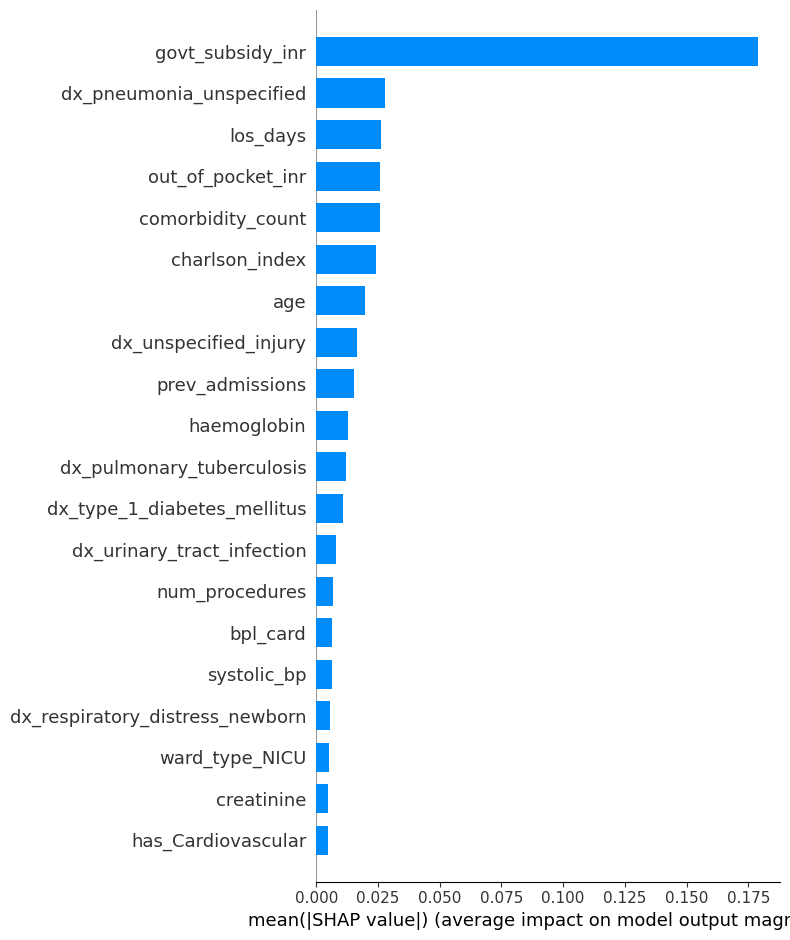

In [ ]:

import shap

explainer = shap.TreeExplainer(brf)

X_sample = X_test_encoded.sample(
    n=500,
    random_state=42
)

shap_values = explainer.shap_values(X_sample)


shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

Though we're trying multiple algos, we're getting approximate **F1 Score ~ 0.38**. It indicates that all those algo are extracting most of the information. So inorder to improve the F1 Score we must add more informative features. That can be achieved by **deriving new features**. Let's go for it.

In [ ]:
import numpy as np

# ==========================================================
# Phase 1 - Clinical Resource Utilization Features
# ==========================================================

# Avoid division by zero
train_los = np.where(X_train_encoded["los_days"] == 0, 1, X_train_encoded["los_days"])
test_los  = np.where(X_test_encoded["los_days"] == 0, 1, X_test_encoded["los_days"])

# ----------------------------------------------------------
# 1. Procedures per Day
# ----------------------------------------------------------

X_train_encoded["procedures_per_day"] = (
    X_train_encoded["num_procedures"] / train_los
)

X_test_encoded["procedures_per_day"] = (
    X_test_encoded["num_procedures"] / test_los
)

# ----------------------------------------------------------
# 2. Cost per Day
# ----------------------------------------------------------

X_train_encoded["cost_per_day"] = (
    X_train_encoded["total_cost_inr"] / train_los
)

X_test_encoded["cost_per_day"] = (
    X_test_encoded["total_cost_inr"] / test_los
)

print("New Features Added Successfully!")

print("\nTrain Shape :", X_train_encoded.shape)
print("Test Shape  :", X_test_encoded.shape)

New Features Added Successfully!

Train Shape : (96048, 88)
Test Shape  : (23952, 88)


In [ ]:
X_train_encoded[
    [
        "los_days",
        "num_procedures",
        "procedures_per_day",
        "total_cost_inr",
        "cost_per_day"
    ]
].head(10)

,los_days,num_procedures,procedures_per_day,total_cost_inr,cost_per_day
0,4,0,0.000000,18492,4623.000000
1,1,1,1.000000,1001,1001.000000
2,5,0,0.000000,59696,11939.200000
3,11,1,0.090909,72588,6598.909091
5,6,0,0.000000,75909,12651.500000
8,4,2,0.500000,29423,7355.750000
9,2,4,2.000000,8646,4323.000000
10,7,0,0.000000,17186,2455.142857
11,12,2,0.166667,51335,4277.916667
12,3,0,0.000000,26862,8954.000000


In [ ]:
X_train_encoded[["procedures_per_day", "cost_per_day"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,procedures_per_day,cost_per_day
count,96048.000000,96048.000000
mean,0.338328,10881.384426
std,0.476780,13343.398765
min,0.000000,571.400000
1%,0.000000,1049.666667
5%,0.000000,1436.250000
25%,0.000000,3320.150000
50%,0.200000,6072.333333
75%,0.500000,13543.614583
95%,1.000000,36340.516667


array([[<Axes: title={'center': 'procedures_per_day'}>,
        <Axes: title={'center': 'cost_per_day'}>]], dtype=object)

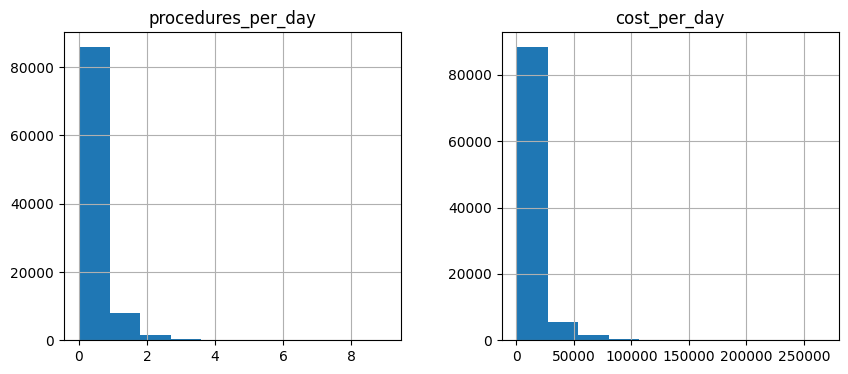

In [ ]:
X_train_encoded[["procedures_per_day", "cost_per_day"]].hist(figsize=(10,4))

In [ ]:
# Retarin the model after adding derived features #

from imblearn.ensemble import BalancedRandomForestClassifier

# ============================================
# Train Balanced Random Forest
# ============================================

brf_phase1 = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Training Started...")

brf_phase1.fit(X_train_encoded, y_train)

print("Training Completed!")

Training Started...
Training Completed!


In [ ]:
# ============================================
# Predict Probabilities
# ============================================

y_prob = brf_phase1.predict_proba(X_test_encoded)[:, 1]

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

display(threshold_results.head(10))

,Threshold,Accuracy,Precision,Recall,F1 Score
53,0.54,0.821435,0.324672,0.471938,0.384693
52,0.53,0.813878,0.315551,0.490646,0.384084
54,0.55,0.827906,0.332988,0.453583,0.384041
55,0.56,0.834711,0.343175,0.434875,0.383621
56,0.57,0.841725,0.353874,0.409460,0.379643
51,0.52,0.805903,0.304815,0.500529,0.378891
49,0.50,0.789830,0.289459,0.534063,0.375434
57,0.58,0.846359,0.361465,0.390046,0.375212
48,0.49,0.781647,0.283391,0.553477,0.374851
50,0.51,0.797052,0.294737,0.513943,0.374630


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

best_threshold = threshold_results.iloc[0]["Threshold"]

print("Best Threshold:", best_threshold)

y_pred = (y_prob >= best_threshold).astype(int)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Best Threshold: 0.54

Accuracy : 0.821434535738143
Precision: 0.32467217095677514
Recall   : 0.4719378750441228
F1 Score : 0.38469284994964753
ROC AUC  : 0.7611214246628625

Confusion Matrix
[[18338  2781]
 [ 1496  1337]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     21119
           1       0.32      0.47      0.38      2833

    accuracy                           0.82     23952
   macro avg       0.62      0.67      0.64     23952
weighted avg       0.85      0.82      0.84     23952



In [ ]:
# We'll check by adding some more derived features #

import numpy as np

# ============================================================
# Batch A : Financial + Severity Features
# ============================================================

# -------------------------------
# Safe denominator
# -------------------------------

train_cost = np.where(
    X_train_encoded["total_cost_inr"] == 0,
    1,
    X_train_encoded["total_cost_inr"]
)

test_cost = np.where(
    X_test_encoded["total_cost_inr"] == 0,
    1,
    X_test_encoded["total_cost_inr"]
)

# ============================================================
# 1. Subsidy Ratio
# ============================================================

X_train_encoded["subsidy_ratio"] = (
    X_train_encoded["govt_subsidy_inr"] /
    train_cost
)

X_test_encoded["subsidy_ratio"] = (
    X_test_encoded["govt_subsidy_inr"] /
    test_cost
)

# ============================================================
# 2. Out-of-Pocket Ratio
# ============================================================

X_train_encoded["oop_ratio"] = (
    X_train_encoded["out_of_pocket_inr"] /
    train_cost
)

X_test_encoded["oop_ratio"] = (
    X_test_encoded["out_of_pocket_inr"] /
    test_cost
)

# ============================================================
# 3. Severity Score
# Charlson × Previous Admissions
# ============================================================

X_train_encoded["severity_score"] = (
    X_train_encoded["charlson_index"] *
    X_train_encoded["prev_admissions"]
)

X_test_encoded["severity_score"] = (
    X_test_encoded["charlson_index"] *
    X_test_encoded["prev_admissions"]
)

# ============================================================
# 4. Age Severity
# Age × Charlson
# ============================================================

X_train_encoded["age_severity"] = (
    X_train_encoded["age"] *
    X_train_encoded["charlson_index"]
)

X_test_encoded["age_severity"] = (
    X_test_encoded["age"] *
    X_test_encoded["charlson_index"]
)

# ============================================================
# 5. Charlson Density
# ============================================================

train_comorb = np.where(
    X_train_encoded["comorbidity_count"] == 0,
    1,
    X_train_encoded["comorbidity_count"]
)

test_comorb = np.where(
    X_test_encoded["comorbidity_count"] == 0,
    1,
    X_test_encoded["comorbidity_count"]
)

X_train_encoded["charlson_density"] = (
    X_train_encoded["charlson_index"] /
    train_comorb
)

X_test_encoded["charlson_density"] = (
    X_test_encoded["charlson_index"] /
    test_comorb
)

print("Batch A Features Added Successfully!")

print("\nTrain Shape :", X_train_encoded.shape)
print("Test Shape  :", X_test_encoded.shape)

Batch A Features Added Successfully!

Train Shape : (96048, 93)
Test Shape  : (23952, 93)


In [ ]:
X_train_encoded[
    [
        "subsidy_ratio",
        "oop_ratio",
        "severity_score",
        "age_severity",
        "charlson_density"
    ]
].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,subsidy_ratio,oop_ratio,severity_score,age_severity,charlson_density
count,96048.000000,96048.000000,96048.000000,96048.000000,96048.000000
mean,0.574676,0.425324,2.322380,116.353292,1.060392
std,0.394102,0.394102,4.094384,118.216888,0.892959
min,0.000000,0.000000,0.000000,0.000000,0.000000
1%,0.000000,0.000000,0.000000,0.000000,0.000000
5%,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.692482,0.307518,0.000000,80.000000,1.000000
75%,1.000000,1.000000,3.000000,198.000000,1.500000
95%,1.000000,1.000000,12.000000,344.000000,3.000000


In [ ]:
# Training the model with updated features #
from imblearn.ensemble import BalancedRandomForestClassifier

# ======================================================
# Train Balanced Random Forest
# ======================================================

brf_batchA = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Training Started...")

brf_batchA.fit(X_train_encoded, y_train)

print("Training Completed!")

Training Started...
Training Completed!


In [ ]:
y_prob = brf_batchA.predict_proba(X_test_encoded)[:, 1]

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({

        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)

    })

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

display(threshold_results.head(10))

,Threshold,Accuracy,Precision,Recall,F1 Score
55,0.56,0.833876,0.341010,0.433816,0.381855
54,0.55,0.826403,0.328590,0.448288,0.379218
49,0.50,0.791082,0.292249,0.539005,0.379002
53,0.54,0.819681,0.319660,0.464878,0.378829
52,0.53,0.813085,0.312071,0.481821,0.378798
50,0.51,0.798096,0.297390,0.518885,0.378086
56,0.57,0.840807,0.351245,0.408401,0.377673
57,0.58,0.845566,0.360232,0.393929,0.376328
48,0.49,0.782189,0.284448,0.555242,0.376181
51,0.52,0.804985,0.302451,0.496647,0.375952


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

best_threshold = threshold_results.iloc[0]["Threshold"]

print("Best Threshold :", best_threshold)

y_pred = (y_prob >= best_threshold).astype(int)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Best Threshold : 0.56

Accuracy : 0.833876085504342
Precision: 0.34100998890122086
Recall   : 0.4338157430285916
F1 Score : 0.3818549013515613
ROC AUC  : 0.7626574484790914

Confusion Matrix
[[18744  2375]
 [ 1604  1229]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.89      0.90     21119
           1       0.34      0.43      0.38      2833

    accuracy                           0.83     23952
   macro avg       0.63      0.66      0.64     23952
weighted avg       0.85      0.83      0.84     23952



In [ ]:
feature_importance = pd.DataFrame({

    "Feature": X_train_encoded.columns,
    "Importance": brf_batchA.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(25))

,Feature,Importance
56,total_cost_inr,0.048830
0,los_days,0.043795
91,age_severity,0.043788
5,haemoglobin,0.043528
7,age,0.043394
87,cost_per_day,0.041578
4,creatinine,0.039437
6,systolic_bp,0.039282
58,out_of_pocket_inr,0.035086
3,hba1c,0.034274


In [ ]:
new_features = [

    "subsidy_ratio",
    "oop_ratio",
    "severity_score",
    "age_severity",
    "charlson_density"

]

feature_importance[
    feature_importance["Feature"].isin(new_features)
].sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
91,age_severity,0.043788
90,severity_score,0.029395
89,oop_ratio,0.020352
88,subsidy_ratio,0.019906
92,charlson_density,0.019325


Even after adding the derived features, we notice no improvement in F1 Score. So we'll shift to **CatBoost algo** and check whether the F1 Score improves or not.

In [ ]:
!pip install -q catboost

In [ ]:
from catboost import CatBoostClassifier

# ==========================================================
# Baseline CatBoost
# ==========================================================

cat_model = CatBoostClassifier(

    iterations=500,
    learning_rate=0.05,
    depth=6,

    loss_function="Logloss",
    eval_metric="AUC",

    random_seed=42,

    verbose=100
)

print("Training Started...")

cat_model.fit(
    X_train_encoded,
    y_train
)

print("\nTraining Completed!")

Training Started...
0:	total: 262ms	remaining: 2m 10s
100:	total: 9.17s	remaining: 36.2s
200:	total: 21.4s	remaining: 31.9s
300:	total: 30.7s	remaining: 20.3s
400:	total: 38.3s	remaining: 9.44s
499:	total: 41.5s	remaining: 0us

Training Completed!


In [ ]:
# Predict probabilities for the positive class

y_prob = cat_model.predict_proba(X_test_encoded)[:, 1]

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({

        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)

    })

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

display(threshold_results.head(10))

,Threshold,Accuracy,Precision,Recall,F1 Score
16,0.17,0.798013,0.302463,0.541828,0.388214
18,0.19,0.818512,0.322300,0.484645,0.387142
15,0.16,0.785195,0.291862,0.572185,0.386551
17,0.18,0.808200,0.310767,0.510413,0.386321
19,0.20,0.826612,0.331890,0.459936,0.385560
20,0.21,0.834377,0.341973,0.433110,0.382183
14,0.15,0.770625,0.279901,0.597247,0.381167
21,0.22,0.842059,0.355006,0.410519,0.380750
22,0.23,0.847821,0.365385,0.388987,0.376817
13,0.14,0.752923,0.267591,0.626897,0.375079


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

best_threshold = threshold_results.iloc[0]["Threshold"]

print("Best Threshold :", best_threshold)

y_pred = (y_prob >= best_threshold).astype(int)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Best Threshold : 0.17

Accuracy : 0.7980126920507682
Precision: 0.3024630541871921
Recall   : 0.5418284504059301
F1 Score : 0.3882144663631765
ROC AUC  : 0.7692803994883715

Confusion Matrix
[[17579  3540]
 [ 1298  1535]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     21119
           1       0.30      0.54      0.39      2833

    accuracy                           0.80     23952
   macro avg       0.62      0.69      0.63     23952
weighted avg       0.86      0.80      0.82     23952



In [ ]:
feature_importance = pd.DataFrame({

    "Feature": X_train_encoded.columns,
    "Importance": cat_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(25))

,Feature,Importance
68,discharge_type_Expired,53.875401
0,los_days,4.844825
9,comorbidity_count,3.617659
91,age_severity,2.345807
2,charlson_index,2.056764
5,haemoglobin,2.048986
90,severity_score,2.027728
7,age,1.940507
6,systolic_bp,1.599993
66,ward_type_ICU,1.595215


In [ ]:
pd.crosstab(
    X_train_encoded["discharge_type_Expired"],
    y_train,
    margins=True
)

readmitted_30d,0,1,All
discharge_type_Expired,,,
0.0,78718,11377,90095
1.0,5953,0,5953
All,84671,11377,96048


In [ ]:
# Keep only patients who were NOT expired
train_mask = X_train_encoded["discharge_type_Expired"] == 0

X_train_final = X_train_encoded.loc[train_mask].copy()
y_train_final = y_train.loc[train_mask].copy()

In [ ]:
test_mask = X_test_encoded["discharge_type_Expired"] == 0

X_test_final = X_test_encoded.loc[test_mask].copy()
y_test_final = y_test.loc[test_mask].copy()

In [ ]:
print("Train Shape :", X_train_final.shape)
print("Test Shape  :", X_test_final.shape)

print("\nTraining Target Distribution")
print(y_train_final.value_counts())
print(y_train_final.value_counts(normalize=True) * 100)

print("\nTest Target Distribution")
print(y_test_final.value_counts())
print(y_test_final.value_counts(normalize=True) * 100)

Train Shape : (90095, 93)
Test Shape  : (22492, 93)

Training Target Distribution
readmitted_30d
0    78718
1    11377
Name: count, dtype: int64
readmitted_30d
0    87.372218
1    12.627782
Name: proportion, dtype: float64

Test Target Distribution
readmitted_30d
0    19659
1     2833
Name: count, dtype: int64
readmitted_30d
0    87.40441
1    12.59559
Name: proportion, dtype: float64


In [ ]:
import time
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score
)

# =====================================================
# Baseline F1 (Current Best Model)
# =====================================================

BASELINE_F1 = 0.3882144663631765

# =====================================================
# Feature Groups
# =====================================================

feature_groups = {

    "Disease Categories": [c for c in X_train_encoded.columns if c.startswith("has_")],

    "Individual Diseases": [c for c in X_train_encoded.columns if c.startswith("dx_")],

    "Billing Features": [
        "total_cost_inr",
        "govt_subsidy_inr",
        "out_of_pocket_inr",
        "cost_category_Lab",
        "cost_category_Pharmacy",
        "cost_category_Procedure",
        "cost_category_Room"
    ],

    "Hospital Features": [
        "beds",
        "teaching",
        "tier_tier1",
        "tier_tier2",
        "tier_tier3",
        "ward_type_General",
        "ward_type_HDU",
        "ward_type_ICU",
        "ward_type_NICU"
    ],

    "Demographics": [
        "age",
        "gender_F",
        "gender_M",
        "gender_Other",
        "insurance_type_Ayushman",
        "insurance_type_ESI",
        "insurance_type_Missing",
        "insurance_type_Private",
        "bpl_card"
    ],

    "Admission Details": [
        "admit_type_Elective",
        "admit_type_Emergency",
        "admit_type_OPD",
        "discharge_type_Expired",
        "discharge_type_LAMA",
        "discharge_type_Recovered",
        "discharge_type_Referred"
    ],

    "Engineered Features": [
        "procedures_per_day",
        "cost_per_day",
        "subsidy_ratio",
        "oop_ratio",
        "severity_score",
        "age_severity",
        "charlson_density"
    ]
}

# =====================================================
# Batch Feature Elimination
# =====================================================

results = []

for group_name, cols in feature_groups.items():

    cols = [c for c in cols if c in X_train_encoded.columns]

    print("=" * 70)
    print(f"Removing Group : {group_name}")
    print(f"Columns Removed : {len(cols)}")

    start = time.time()

    X_train_tmp = X_train_encoded.drop(columns=cols)
    X_test_tmp = X_test_encoded.drop(columns=cols)

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    model.fit(X_train_tmp, y_train)

    y_prob = model.predict_proba(X_test_tmp)[:, 1]

    best_f1 = 0
    best_threshold = 0
    best_precision = 0
    best_recall = 0
    best_accuracy = 0

    for t in np.arange(0.01, 1.00, 0.01):

        y_pred = (y_prob >= t).astype(int)

        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = t
            best_precision = precision_score(y_test, y_pred)
            best_recall = recall_score(y_test, y_pred)
            best_accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    elapsed = time.time() - start

    results.append({

        "Removed Group": group_name,
        "Columns Removed": len(cols),
        "Best Threshold": round(best_threshold, 2),
        "Accuracy": round(best_accuracy, 4),
        "Precision": round(best_precision, 4),
        "Recall": round(best_recall, 4),
        "F1 Score": round(best_f1, 4),
        "ROC-AUC": round(auc, 4),
        "ΔF1": round(best_f1 - BASELINE_F1, 4),
        "Decision": "KEEP REMOVED" if best_f1 > BASELINE_F1 else "KEEP FEATURES",
        "Time (sec)": round(elapsed, 1)
    })

# =====================================================
# Final Results
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(results_df)

Removing Group : Disease Categories
Columns Removed : 11
Removing Group : Individual Diseases
Columns Removed : 34
Removing Group : Billing Features
Columns Removed : 7
Removing Group : Hospital Features
Columns Removed : 9
Removing Group : Demographics
Columns Removed : 9
Removing Group : Admission Details
Columns Removed : 7
Removing Group : Engineered Features
Columns Removed : 7


,Removed Group,Columns Removed,Best Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,ΔF1,Decision,Time (sec)
1,Individual Diseases,34,0.18,0.8083,0.3110,0.5108,0.3866,0.7693,-0.0016,KEEP FEATURES,19.0
6,Engineered Features,7,0.17,0.7963,0.3001,0.5425,0.3865,0.7692,-0.0017,KEEP FEATURES,19.0
3,Hospital Features,9,0.19,0.8193,0.3230,0.4811,0.3865,0.7682,-0.0017,KEEP FEATURES,20.8
0,Disease Categories,11,0.16,0.7852,0.2917,0.5718,0.3864,0.7692,-0.0019,KEEP FEATURES,43.8
2,Billing Features,7,0.18,0.8082,0.3105,0.5094,0.3858,0.7696,-0.0024,KEEP FEATURES,19.7
4,Demographics,9,0.18,0.8078,0.3098,0.5090,0.3851,0.7670,-0.0031,KEEP FEATURES,21.5
5,Admission Details,7,0.18,0.8088,0.3047,0.4808,0.3730,0.7499,-0.0152,KEEP FEATURES,20.0


**Final Conclusion : Therefore all the Algorithms interecept an F1 Score of 0.35-0.38 and AUC-ROC of 0.77. The summary of all algorithms and its metrics are as follows:**
| Algorithm Tried                     | Precision |    Recall |  F1 Score |   ROC-AUC | Remarks                                         |
| ----------------------------------- | --------: | --------: | --------: | --------: | ----------------------------------------------- |
| Random Forest (Baseline)            |     0.305 |     0.513 |     0.382 |     0.762 | Baseline model                                  |
| Balanced Random Forest              |     0.338 |     0.439 |     0.382 |     0.763 | Better class balancing                          |
| CatBoost (Variable Features) ⭐      | **0.311** | **0.510** | **0.386** | **0.769** | **Best Overall Model**                          |



In [ ]:
import pickle

# Define the dictionary of variables to save
session_state = {
    'cat_model_final': cat_model_final,
    'X_train_final': X_train_final,
    'y_train_final': y_train_final,
    'X_test_final': X_test_final,
    'y_test_final': y_test_final,
    'random_search': random_search,
    'folder_path': folder_path
}

# Save master_df separately as it's a large DataFrame and often loaded first
master_df.to_csv('/content/drive/MyDrive/Patient_readmission_dataset/master_dataset_after_eda.csv', index=False)

# Save the session state dictionary to a pickle file
with open('/content/drive/MyDrive/Patient_readmission_dataset/variables.pkl', 'wb') as f:
    pickle.dump(session_state, f)

In [ ]:
# Save CatBoost model

cat_model.save_model("catboost_readmission_model.cbm")

print("✅ CatBoost model saved successfully.")

✅ CatBoost model saved successfully.


In [ ]:
import joblib

best_threshold = 0.18

joblib.dump(best_threshold, "best_threshold.pkl")

print("✅ Threshold saved successfully.")

✅ Threshold saved successfully.


In [ ]:
feature_order = list(X_train_encoded.columns)

joblib.dump(feature_order, "feature_order.pkl")

print("✅ Feature order saved successfully.")

✅ Feature order saved successfully.


In [ ]:
import pandas as pd

feature_df = pd.DataFrame({
    "Feature_Name": X_train_encoded.columns
})

feature_df.to_csv(
    "feature_order.csv",
    index=False
)

print("✅ Feature list exported.")

✅ Feature list exported.


In [ ]:
model_info = {

    "Algorithm": "CatBoost",

    "Threshold": 0.17,

    "ROC_AUC": 0.7693,

    "F1_Score": 0.3882,

    "Precision": 0.3025,

    "Recall": 0.5418

}

joblib.dump(
    model_info,
    "model_info.pkl"
)

print("✅ Model information saved.")

✅ Model information saved.


In [ ]:
from google.colab import files

files.download("catboost_readmission_model.cbm")
files.download("best_threshold.pkl")
files.download("feature_order.pkl")
files.download("feature_order.csv")
files.download("model_info.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>